In [ ]:
!pip install -q augly
!pip install -q librosa
import os
from google.colab import drive
if not os.path.exists('/content/drive'):
   drive.mount('/content/drive')
import re
import librosa
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import sys

# Fix for augly/torchaudio compatibility in Python 3.12 / Torchaudio 2.x
import torchaudio

# Define a mock class to replace the missing sox_effects module
class SoxPatch:
    @staticmethod
    def apply_effects_tensor(tensor, sample_rate, effects, channels_first=True):
        # Most augly transforms just need the tensor returned if sox isn't handling it
        return tensor, sample_rate
# Inject the patch into sys.modules so augly can find it
if not hasattr(torchaudio, 'sox_effects'):
    mock_sox = SoxPatch()
    sys.modules['torchaudio.sox_effects'] = mock_sox
    torchaudio.sox_effects = mock_sox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 44.2 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
!git clone https://github.com/mona0101/Final-year-project-2026.git
%cd Final-year-project-2026

Cloning into 'Final-year-project-2026'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 79 (delta 38), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 718.68 KiB | 10.89 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/content/Final-year-project-2026


In [ ]:
import os
import torch
from torch.utils.data import DataLoader
# Run this once before initializing the dataset
!cp "/content/drive/MyDrive/Colab Notebooks/Drone_Train.h5" "/content/Drone_Train.h5"
!cp "/content/drive/MyDrive/Colab Notebooks/Drone_Validation.h5" "/content/Drone_Validation.h5"
!cp "/content/drive/MyDrive/Colab Notebooks/Drone_Test.h5" "/content/Drone_Test.h5"

#This code reads the HDF5 file and generates both Log-Mel and MFCC features.

Also RF, videos

In [ ]:
import os
import h5py
import torch
import numpy as np
import librosa
from torch.utils.data import Dataset
from PIL import Image

class DroneFusionDatasetH5(Dataset):
    def __init__(
        self,
        h5_path,
        transform=None,  # Dict containing your get_audio_transform, get_img_transform, etc.
        audio_feature_type='mfcc',
        modalities=['audio', 'video', 'rf'],
        is_training=True,
        n_mfcc=40,
        n_fft=2048,
        hop_length=512,
        n_mels=64,
        segment_length=0.25
    ):
        self.h5_path = h5_path
        self.audio_feature_type = audio_feature_type.lower()
        self.modalities = [m.lower() for m in modalities]
        self.is_training = is_training

        self.transform = transform or {}
        self.n_mfcc = n_mfcc
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.segment_length = segment_length

        if not os.path.exists(self.h5_path):
            raise FileNotFoundError(f"HDF5 file not found at: {self.h5_path}")

        # Extract metadata
        with h5py.File(self.h5_path, 'r') as f:
            self.length = len(f['labels'])
            # Native SR from the H5 attributes (set during packing)
            self.native_sr = int(f.attrs.get('sr', 44100))

    def _extract_logmel(self, y, sr):
        # Exact logic from your original loader
        target_frames = int(np.ceil(self.segment_length / (138 / sr)))

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=1024, hop_length=138,
            n_mels=self.n_mels, power=2.0
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Z-score normalization
        log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

        if log_mel.shape[1] < target_frames:
            pad_width = target_frames - log_mel.shape[1]
            log_mel = np.pad(log_mel, ((0,0),(0,pad_width)), mode='constant')
        else:
            log_mel = log_mel[:, :target_frames]

        return torch.from_numpy(log_mel).unsqueeze(0).float()

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Open inside getitem for DataLoader worker safety
        with h5py.File(self.h5_path, 'r') as f:
            # 1. Label
            label = torch.tensor(f['labels'][idx], dtype=torch.long)

            # 2. Audio Processing
            audio_tensor = torch.empty(0)
            if 'audio' in self.modalities:
                waveform = f['audio'][idx].astype(np.float32)
                sr = self.native_sr

                # Apply your custom get_audio_transform (augly/logmel_augment)
                if 'audio' in self.transform:
                    waveform, sr = self.transform['audio'](waveform, sr)

                if self.audio_feature_type == 'logmel':
                    max_val = np.max(np.abs(waveform))
                    if max_val > 0: waveform /= max_val
                    audio_tensor = self._extract_logmel(waveform, sr)
                else:
                    # MFCC "Diff Sampling" [::3]
                    waveform_sub = np.asfortranarray(waveform[::3])
                    mfcc = librosa.feature.mfcc(
                        y=waveform_sub, sr=sr, n_mfcc=self.n_mfcc,
                        n_fft=self.n_fft, hop_length=self.hop_length
                    )
                    pad_width = max(0, self.n_mfcc - mfcc.shape[1])
                    if pad_width > 0:
                        mfcc = np.pad(mfcc, ((0,0),(0,pad_width)), mode='constant')
                    audio_tensor = torch.from_numpy(mfcc).float().unsqueeze(0)

            # 3. Video Processing (Using your get_img_transform)
            video_tensor = torch.empty(0)
            if 'video' in self.modalities:
                video_data = f['video'][idx]
                v_trans = self.transform.get('video')
                if v_trans:
                    # Logic: uint8 -> PIL -> your Compose (ToTensor + Augments + Normalize)
                    v_frames = [v_trans(Image.fromarray(video_data[i])) for i in range(len(video_data))]
                    video_tensor = torch.stack(v_frames)

            # 4. RF Processing (Using your get_rf_transform)
            rf_tensor = torch.empty(0)
            if 'rf' in self.modalities:
                rf_data = f['rf'][idx]
                rf_trans = self.transform.get('rf')
                if rf_trans:
                    # Logic: uint8 -> PIL -> your Compose (Resize + ToTensor + rf_aug + Normalize)
                    rf_frames = [rf_trans(Image.fromarray(rf_data[i])) for i in range(len(rf_data))]
                    rf_tensor = torch.stack(rf_frames)

        return audio_tensor, video_tensor, rf_tensor, label

In [ ]:


# --- 2. Configuration Class ---
class Args:
    dataset_dir = '/content/'
    batch_size = 32
    feature_type = 'mfcc'  # Change to 'logmel' to update parameters below

    # Dynamic parameter selection based on original loader requirements
    n_mfcc = 40
    n_mels = 64 if feature_type == 'logmel' else 40

    num_workers = 2
    pin_memory = True
    modalities = ['video']
    crop_size = 112

args = Args()

# --- 3. Setup Transforms ---
from augmentation import get_audio_transform, get_img_transform, get_rf_transform

train_transform = {
    'audio': get_audio_transform(args, is_training=True, feature_type=args.feature_type),
    'video': get_img_transform(args, is_training=True, augment=True),
    'rf': get_rf_transform(args, is_training=True, augment=False)
}

val_transform = {
    'audio': get_audio_transform(args, is_training=False, feature_type=args.feature_type),
    'video': get_img_transform(args, is_training=False, augment=False),
    'rf': get_rf_transform(args, is_training=False, augment=False)
}

# --- 4. Initialize Datasets & Loaders ---
train_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Train.h5'),
    transform=train_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=True
)

val_dataset = DroneFusionDatasetH5(
    h5_path=os.path.join(args.dataset_dir, 'Drone_Validation.h5'),
    transform=val_transform,
    audio_feature_type=args.feature_type,
    n_mfcc=args.n_mfcc,
    n_mels=args.n_mels,
    modalities=args.modalities,
    is_training=False
)

loaders = {
    'train': DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                        num_workers=args.num_workers, pin_memory=args.pin_memory),
    'val': DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False,
                      num_workers=args.num_workers, pin_memory=args.pin_memory)
}

# --- 5. Final Printing and Verification ---
print(f"--- Dataset Summary ---")
print(f"Train Samples: {len(train_dataset)} | Batches: {len(loaders['train'])}")
print(f"Val Samples:   {len(val_dataset)} | Batches: {len(loaders['val'])}\n")

print(f"--- Input Shape Verification ---")
try:
    audio_b, video_b, rf_b, label_b = next(iter(loaders['train']))
    print(f"Audio Shape: {audio_b.shape}")
    print(f"Video Shape: {video_b.shape}")
    print(f"RF Shape:    {rf_b.shape}")
    print(f"Label Shape: {label_b.shape}")
except Exception as e:
    print(f"Error during verification: {e}")

--- Dataset Summary ---
Train Samples: 8480 | Batches: 265
Val Samples:   1280 | Batches: 40

--- Input Shape Verification ---
Audio Shape: torch.Size([32, 0])
Video Shape: torch.Size([32, 7, 3, 112, 112])
RF Shape:    torch.Size([32, 0])
Label Shape: torch.Size([32])


#These are the functions I always use for plotting, training, and testing. Feel free to replace them if you prefer a different coding style.

In [ ]:

# ==========================================
# MODULAR TRAINING & EVALUATION (STATIC LABELS + LATENCY)
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
import copy
import time

# --------------------------
# 1️⃣ Training Function
# --------------------------
def train_unimodal(model, dataloaders, device, criterion, optimizer, num_epochs=10, modal_num=0):
    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc']}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        for phase in ['train','val']:
            model.train() if phase=='train' else model.eval()
            running_loss, all_preds, all_labels = 0.0, [], []

            for batch in tqdm(dataloaders[phase], desc=f"{phase.upper()}", leave=False):
                inputs = batch[modal_num].to(device).float()
                labels = batch[-1].to(device).float()

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase=='train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    if phase=='train':
                        loss.backward()

                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                preds = (outputs>0.5).long()
                all_preds.append(preds.detach())
                all_labels.append(labels.detach().long())

            # Metrics
            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            y_true = torch.cat(all_labels).cpu().numpy()
            y_pred = torch.cat(all_preds).cpu().numpy()
            epoch_acc = accuracy_score(y_true, y_pred)

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f"{phase.upper()} -> Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase == 'val':
                # 1. Update the scheduler every epoch based on validation loss
                scheduler.step(epoch_loss) # new addedd from me experment 1

                # 2. Track and print the learning rate
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Current Learning Rate: {current_lr:.6f}")

                # 3. Save the best model weights
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    print(f"*** New Best Model Saved (Acc: {best_acc:.4f}) ***")

    model.load_state_dict(best_model_wts)
    return model, history

# --------------------------
# 2️⃣ Testing Function (with latency)
# --------------------------
def test_unimodal(model, dataloader, device, modal_num=0, dataset_name="Dataset"):
    model.eval()
    all_preds, all_labels = [], []
    total_time, total_samples = 0, 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Testing {dataset_name}"):
            inputs = batch[modal_num].to(device).float()
            labels = batch[-1].to(device).long()

            # Timing
            if device.type=='cuda': torch.cuda.synchronize()
            start = time.time()
            outputs = model(inputs)
            if device.type=='cuda': torch.cuda.synchronize()
            total_time += (time.time()-start)

            preds = (outputs>0.5).long()
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            total_samples += inputs.size(0)

    # Metrics
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    avg_ms = (total_time / total_samples) * 1000
    fps = 1000 / avg_ms

    print(f"\n===== {dataset_name} Results =====")
    print(f"Accuracy: {accuracy:.4f} | F1 (macro): {f1.mean():.4f}")
    print(f"Latency: {avg_ms:.2f} ms/sample | FPS: {fps:.2f}")
    print("===============================\n")

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'avg_ms': avg_ms,
        'fps': fps
    }

# --------------------------
# 3️⃣ Plot Training History
# --------------------------
def plot_training_history(history):
    epochs = range(1,len(history['train_loss'])+1)
    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'],  label='Val Loss')
    plt.title("Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.title("Accuracy vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# --------------------------
# 4️⃣ Confusion Matrix
# --------------------------
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    class_names = ["No-Drone","Drone"]
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --------------------------
# 5️⃣ Per-Class Metrics Bar Plot
# --------------------------
def plot_per_class_metrics_group(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["No-Drone","Drone"]
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    accuracy = [accuracy_score(y_true, y_pred)]*len(class_names)

    paired_colors = ['#1f78b4','#a6cee3','#b2df8a','#33a02c']
    x = np.arange(len(class_names))
    width = 0.2

    plt.figure(figsize=(8,5))
    plt.bar(x-1.5*width, precision, width, label="Precision", color=paired_colors[0])
    plt.bar(x-0.5*width, recall, width, label="Recall", color=paired_colors[1])
    plt.bar(x+0.5*width, f1, width, label="F1-score", color=paired_colors[2])
    plt.bar(x+1.5*width, accuracy, width, label="Accuracy", color=paired_colors[3])
    plt.xticks(x,class_names)
    plt.ylim(0,1)
    plt.ylabel("Score")
    plt.title(f"Per-Class Metrics ({dataset_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --------------------------
# 6️⃣ Classification Report
# --------------------------
def print_classification_report(y_true, y_pred, dataset_name="Dataset"):
    class_names = ["No-Drone","Drone"]
    print(f"\n===== {dataset_name} Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [ ]:
import torch.nn as nn

class ConvBNReLU3D(nn.Module):
    """3D convolution + BatchNorm + ReLU block"""
    def __init__(self, in_planes, out_planes, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv3d(
            in_planes, out_planes,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=False
        )
        self.bn = nn.BatchNorm3d(out_planes)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class Modality3DCNN(nn.Module):
    """Generic 3D CNN for video or RF frames"""
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        # 3D CNN blocks
        self.conv1 = ConvBNReLU3D(in_channels, 32, stride=1)
        self.conv2 = ConvBNReLU3D(32, 64, stride=2)
        self.conv3 = ConvBNReLU3D(64, 128, stride=2)
        self.conv4 = ConvBNReLU3D(128, 256, stride=2)

        # Adaptive pooling → fixed-size feature vector
        self.avg_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        # Classifier
        self.fc = nn.Sequential(nn.Dropout(p=0.5), # new addedd from me experment 1
            nn.Linear(256, num_classes - 1),  # binary classification
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        Args:
            x: [B, T, C, H, W]
               - T = number of frames (video or RF segment)
               - C = channels (3 for RGB, 1 for grayscale)
        """
        if x.ndim != 5:
            raise ValueError("Input tensor must be 5D: [B, T, C, H, W]")

        # Convert to [B, C, T, H, W] for nn.Conv3d
        x = x.permute(0, 2, 1, 3, 4).contiguous()

        # Forward pass
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Global average pooling
        x = self.avg_pool(x)  # [B, 256, 1, 1, 1]
        x = torch.flatten(x, 1)  # [B, 256]

        out = self.fc(x)
        return out.squeeze()


Epoch 1/10


TRAIN -> Loss: 0.3746 | Acc: 0.8327


VAL -> Loss: 0.8896 | Acc: 0.6250
Current Learning Rate: 0.001000
*** New Best Model Saved (Acc: 0.6250) ***

Epoch 2/10


TRAIN -> Loss: 0.2553 | Acc: 0.9017


VAL -> Loss: 0.1449 | Acc: 0.9062
Current Learning Rate: 0.001000
*** New Best Model Saved (Acc: 0.9062) ***

Epoch 3/10


...

VAL -> Loss: 0.0340 | Acc: 1.0000
Current Learning Rate: 0.001000
*** New Best Model Saved (Acc: 1.0000) ***

Epoch 9/10


TRAIN -> Loss: 0.0646 | Acc: 0.9762


VAL -> Loss: 0.0687 | Acc: 0.9906
Current Learning Rate: 0.001000

Epoch 10/10


TRAIN -> Loss: 0.0625 | Acc: 0.9776


VAL -> Loss: 0.0310 | Acc: 1.0000
Current Learning Rate: 0.001000


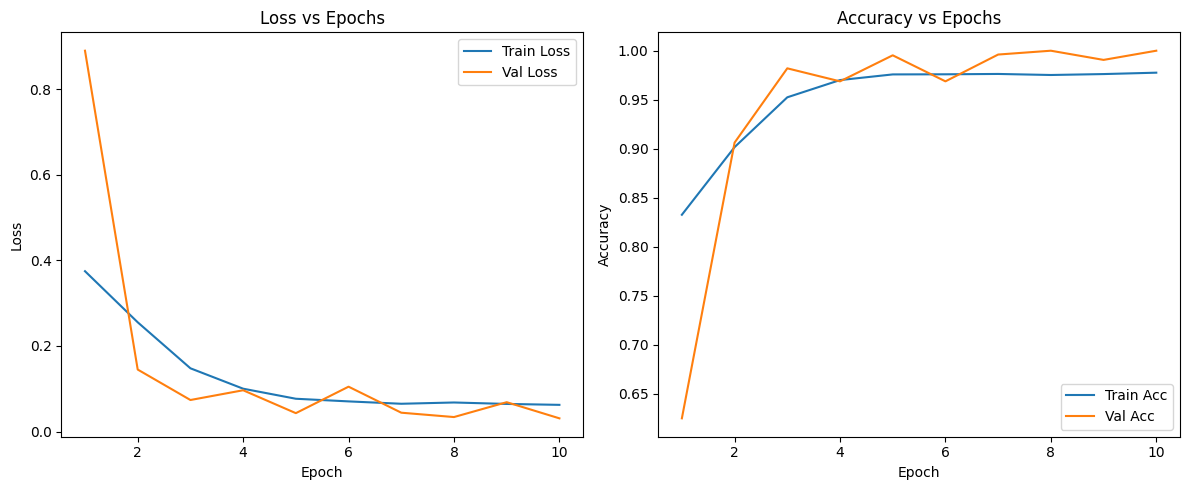

Testing Train:   0%|          | 0/265 [00:03<?, ?it/s]


ValueError: Input tensor must be 5D: [B, T, C, H, W]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Modality3DCNN().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 3️⃣ Training
model, history = train_unimodal(model, loaders, device, criterion, optimizer, num_epochs=10, modal_num=1)

# 2️⃣ رسم loss و accuracy
plot_training_history(history)

# 3️⃣ اختبار كل مجموعة بيانات (مع حساب الوقت)
train_metrics = test_unimodal(model, loaders['train'], device, dataset_name="Train")
val_metrics   = test_unimodal(model, loaders['val'], device, dataset_name="Validation")
#test_metrics  = test_unimodal(model, loaders['test'], device, dataset_name="Test")

# 4️⃣ طباعة classification reports
print_classification_report(train_metrics['y_true'], train_metrics['y_pred'], "Train")
print_classification_report(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
#print_classification_report(test_metrics['y_true'], test_metrics['y_pred'], "Test")

# 5️⃣ رسم مصفوفة الالتباس لكل مجموعة
plot_confusion_matrix(train_metrics['y_true'], train_metrics['y_pred'], "Train Confusion Matrix")
plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], "Validation Confusion Matrix")
#plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], "Test Confusion Matrix")

# 6️⃣ رسم per-class metrics

plot_per_class_metrics_group(train_metrics['y_true'], train_metrics['y_pred'], "Train")
plot_per_class_metrics_group(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
#plot_per_class_metrics_group(test_metrics['y_true'], test_metrics['y_pred'], "Test")

In [ ]:

# 3️⃣ اختبار كل مجموعة بيانات (مع حساب الوقت)
train_metrics = test_unimodal(model, loaders['train'], device, dataset_name="Train", modal_num=1)
val_metrics   = test_unimodal(model, loaders['val'], device, dataset_name="Validation", modal_num=1)
#test_metrics  = test_unimodal(model, loaders['test'], device, dataset_name="Test")



Testing Train: 100%|██████████| 265/265 [03:46<00:00,  1.17it/s]



===== Train Results =====
Accuracy: 0.9811 | F1 (macro): 0.9808
Latency: 1.57 ms/sample | FPS: 635.30



Testing Validation: 100%|██████████| 40/40 [00:18<00:00,  2.14it/s]


===== Validation Results =====
Accuracy: 1.0000 | F1 (macro): 1.0000
Latency: 1.50 ms/sample | FPS: 664.73




===== Train Classification Report =====
              precision    recall  f1-score   support

    No-Drone     0.9992    0.9582    0.9783      3760
       Drone     0.9678    0.9994    0.9833      4720

    accuracy                         0.9811      8480
   macro avg     0.9835    0.9788    0.9808      8480
weighted avg     0.9817    0.9811    0.9811      8480


===== Validation Classification Report =====
              precision    recall  f1-score   support

    No-Drone     1.0000    1.0000    1.0000       480
       Drone     1.0000    1.0000    1.0000       800

    accuracy                         1.0000      1280
   macro avg     1.0000    1.0000    1.0000      1280
weighted avg     1.0000    1.0000    1.0000      1280



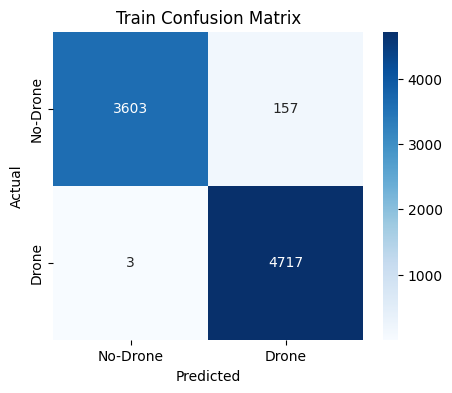

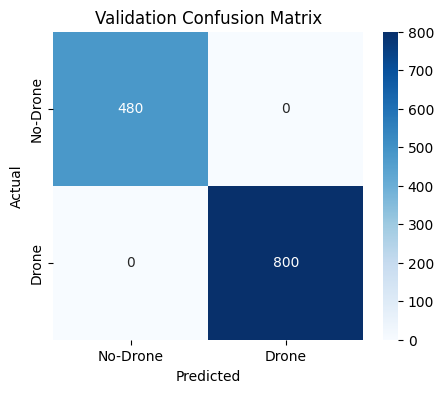

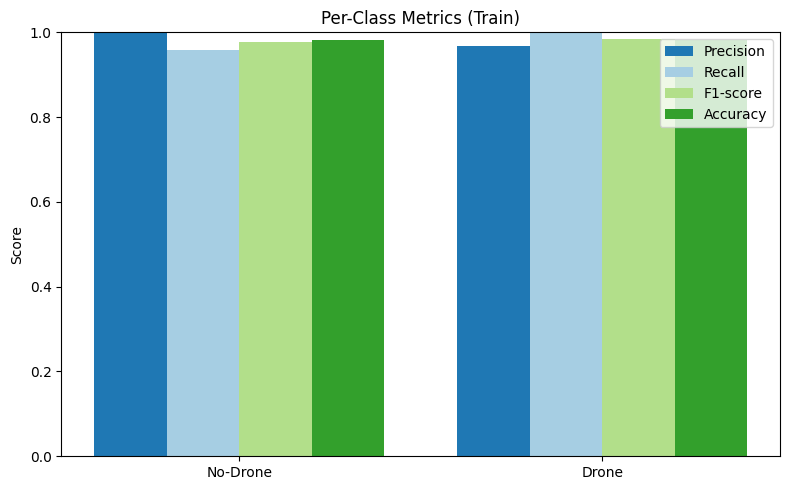

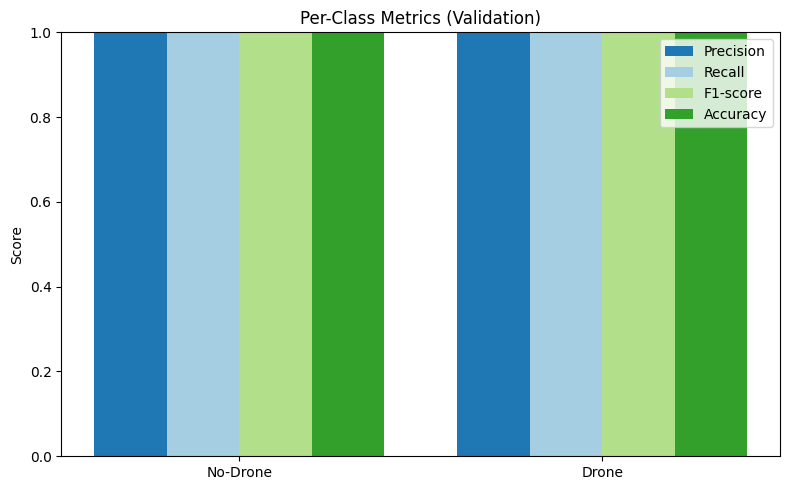

In [ ]:
 #4️⃣ طباعة classification reports
print_classification_report(train_metrics['y_true'], train_metrics['y_pred'], "Train",)
print_classification_report(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
#print_classification_report(test_metrics['y_true'], test_metrics['y_pred'], "Test")

# 5️⃣ رسم مصفوفة الالتباس لكل مجموعة
plot_confusion_matrix(train_metrics['y_true'], train_metrics['y_pred'], "Train Confusion Matrix")
plot_confusion_matrix(val_metrics['y_true'], val_metrics['y_pred'], "Validation Confusion Matrix")
#plot_confusion_matrix(test_metrics['y_true'], test_metrics['y_pred'], "Test Confusion Matrix")

# 6️⃣ رسم per-class metrics

plot_per_class_metrics_group(train_metrics['y_true'], train_metrics['y_pred'], "Train")
plot_per_class_metrics_group(val_metrics['y_true'], val_metrics['y_pred'], "Validation")
#plot_per_class_metrics_group(test_metrics['y_true'], test_metrics['y_pred'], "Test")